<a href="https://colab.research.google.com/github/DoctorNDJonathan/Regression_Climate/blob/main/03_multiple_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Multiple Linear Regression with Feature Engineering

**Project:** Modelling Global Surface Temperature Change Using Regression  
**Dataset:** NASA GISTEMP v4 — Annual Global Mean Temperature Anomaly (1880–Present)  
**Author:** [Your Name]  
**Date:** 2026-06  
**Environment:** Google Colab (Python 3.10+)

---

### Purpose of this notebook
This notebook tests **Research Question RQ4**:

> *Does adding engineered features (decade, rolling 10-year mean, lag-1 anomaly) improve model R² and RMSE compared to Year alone?*

### What is multiple linear regression?

Multiple Linear Regression (MLR) extends simple linear regression from **one predictor to many**:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon$$

Each $\beta_j$ tells you the effect of feature $X_j$ on the target, **holding all other features constant**. This is called the *partial regression coefficient*.

### What is feature engineering?

Feature engineering is the process of creating new input variables from existing data to help the model capture patterns that the raw features alone cannot express. For example:
- **Lag-1** (last year's anomaly) captures temporal momentum — if last year was hot, this year likely is too
- **Rolling mean** captures the underlying long-term trend by smoothing out year-to-year noise
- **Decade indicator** captures structural shifts (e.g. post-industrial acceleration)

> **Reference:** Zheng, A. & Casari, A. (2018). *Feature Engineering for Machine Learning*. O'Reilly Media.  
> Kuhn, M. & Johnson, K. (2019). *Feature Engineering and Selection*. Chapman & Hall/CRC.

### Key risk: Multicollinearity

When features are highly correlated with each other, the model cannot reliably separate their individual effects. This is called **multicollinearity**. We detect it using the **Variance Inflation Factor (VIF)**:
- VIF = 1 → no correlation with other features
- VIF = 5–10 → moderate; monitor
- VIF > 10 → severe; remove or combine features

### Dataset citation
> Lenssen, N., et al., 2024: A GISTEMPv4 observational uncertainty ensemble.  
> *J. Geophys. Res. Atmos.*, 129(17), e2023JD040179.


In [1]:
# =============================================================================
# SECTION 1: IMPORT LIBRARIES
# =============================================================================

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Machine learning ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# --- Evaluation ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --- Statistics ---
from scipy import stats

# --- Display settings ---
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [2]:
# =============================================================================
# SECTION 2: CONFIGURATION
# =============================================================================

DATA_URL     = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
TARGET_COL   = "J-D"
TEST_SIZE    = 0.2
RANDOM_STATE = 42
CV_FOLDS     = 10

# Rolling window size for smoothed trend feature
ROLLING_WINDOW = 10

# Plot colours
COLOR_ACTUAL    = "#3B8BD4"
COLOR_PREDICTED = "#E8593C"
COLOR_BASELINE  = "#888780"
COLOR_RESIDUAL  = "#7B68EE"

print("Configuration set.")


Configuration set.


In [3]:
# =============================================================================
# SECTION 3: DATA LOADING (reused from Notebook 01)
# =============================================================================

def load_gistemp(url: str) -> pd.DataFrame:
    """Load and clean NASA GISTEMP v4 data. See Notebook 01 for full docs."""
    df = pd.read_csv(url, skiprows=1, na_values=["***", "****"])
    month_cols = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]
    annual_cols = ["J-D", "D-N", "DJF", "MAM", "JJA", "SON"]
    keep = ["Year"] + month_cols + annual_cols
    keep = [c for c in keep if c in df.columns]
    df = df[keep].copy()
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)
    for col in df.columns:
        if col != "Year":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.sort_values("Year").reset_index(drop=True)
    return df

df = load_gistemp(DATA_URL)
df = df.dropna(subset=[TARGET_COL]).copy()
print(f"Data loaded: {len(df)} years ({df['Year'].min()}–{df['Year'].max()})")


Data loaded: 146 years (1880–2025)


---
## Step 1 — Feature engineering

We create **four new features** from the existing data. Each captures a different aspect of the temperature signal that `Year` alone cannot express.

| Feature | What it captures | How it is calculated |
|---|---|---|
| `Decade` | Structural period effects | `(Year // 10) * 10` → groups years into decades |
| `Rolling_10yr` | Smoothed long-term trend | 10-year centred rolling mean of anomaly |
| `Lag_1` | Temporal momentum (persistence) | Previous year's anomaly value |
| `Year_squared` | Non-linear acceleration | `Year²` — allows the model to capture a curve |

**Important:** `Rolling_10yr` and `Lag_1` both use the target variable shifted in time. This is valid here because we are using **past** values only — no data leakage from future observations.


In [4]:
# =============================================================================
# SECTION 4: FEATURE ENGINEERING
# =============================================================================

def engineer_features(df: pd.DataFrame, target_col: str,
                      rolling_window: int = 10) -> pd.DataFrame:
    """
    Create engineered features from the raw GISTEMP data.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'Year' and the target column, sorted by Year.
    target_col : str
        Name of the target variable column.
    rolling_window : int
        Window size for rolling mean calculation.

    Returns
    -------
    pd.DataFrame
        Original data plus new feature columns. Rows with NaN from
        lag/rolling operations are dropped.
    """
    df = df.copy()

    # --- Feature 1: Decade ---
    # Groups years into decades (1880, 1890, ..., 2020)
    # Captures structural shifts across different historical periods
    df["Decade"] = (df["Year"] // 10) * 10

    # --- Feature 2: Rolling 10-year mean ---
    # Smooths out year-to-year variability to reveal the underlying trend
    # center=True means 5 years before + 5 years after = 10-year window
    df["Rolling_10yr"] = (df[target_col]
                          .rolling(window=rolling_window, center=True)
                          .mean())

    # --- Feature 3: Lag-1 (previous year's anomaly) ---
    # Captures temporal persistence — consecutive years are correlated
    # shift(1) moves values down by 1 row: row i gets the value from row i-1
    df["Lag_1"] = df[target_col].shift(1)

    # --- Feature 4: Year squared ---
    # Allows the linear model to fit a quadratic (curved) relationship
    # without explicitly using polynomial regression
    df["Year_squared"] = df["Year"] ** 2

    # --- Drop rows with NaN created by rolling/lag operations ---
    rows_before = len(df)
    df = df.dropna().reset_index(drop=True)
    rows_after = len(df)

    print(f"Features engineered. Rows: {rows_before} → {rows_after} "
          f"({rows_before - rows_after} dropped due to rolling/lag NaN)")

    return df


# Apply feature engineering
df_feat = engineer_features(df, TARGET_COL, ROLLING_WINDOW)

# Preview the new features
print(f"\nColumns: {list(df_feat.columns)}")
print(f"\nSample rows:")
df_feat[["Year", TARGET_COL, "Decade", "Rolling_10yr", "Lag_1", "Year_squared"]].head(10)


Features engineered. Rows: 146 → 137 (9 dropped due to rolling/lag NaN)

Columns: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON', 'Decade', 'Rolling_10yr', 'Lag_1', 'Year_squared']

Sample rows:


,Year,J-D,Decade,Rolling_10yr,Lag_1,Year_squared
0,1885,-0.3400,1880,-0.2150,-0.2800,3553225
1,1886,-0.3200,1880,-0.2330,-0.3400,3556996
2,1887,-0.3700,1880,-0.2460,-0.3200,3560769
3,1888,-0.1800,1880,-0.2620,-0.3700,3564544
4,1889,-0.1100,1880,-0.2760,-0.1800,3568321
5,1890,-0.3600,1890,-0.2790,-0.1100,3572100
6,1891,-0.2200,1890,-0.2680,-0.3600,3575881
7,1892,-0.2700,1890,-0.2480,-0.2200,3579664
8,1893,-0.3100,1890,-0.2220,-0.2700,3583449
9,1894,-0.3100,1890,-0.2320,-0.3100,3587236


---
## Step 2 — Feature correlation and multicollinearity analysis

Before building the model, we must check how correlated the features are with:
1. **The target** (higher is better — the feature carries predictive signal)
2. **Each other** (lower is better — high inter-feature correlation means multicollinearity)

If two features are highly correlated with each other (r > 0.9), they provide redundant information and can make coefficient estimates unstable.

We use the **Variance Inflation Factor (VIF)** to formally quantify multicollinearity.

> **Reference:** James, G., Witten, D., Hastie, T. & Tibshirani, R. (2021).  
> *An Introduction to Statistical Learning*, 2nd ed. Springer. Chapter 3.3.3.


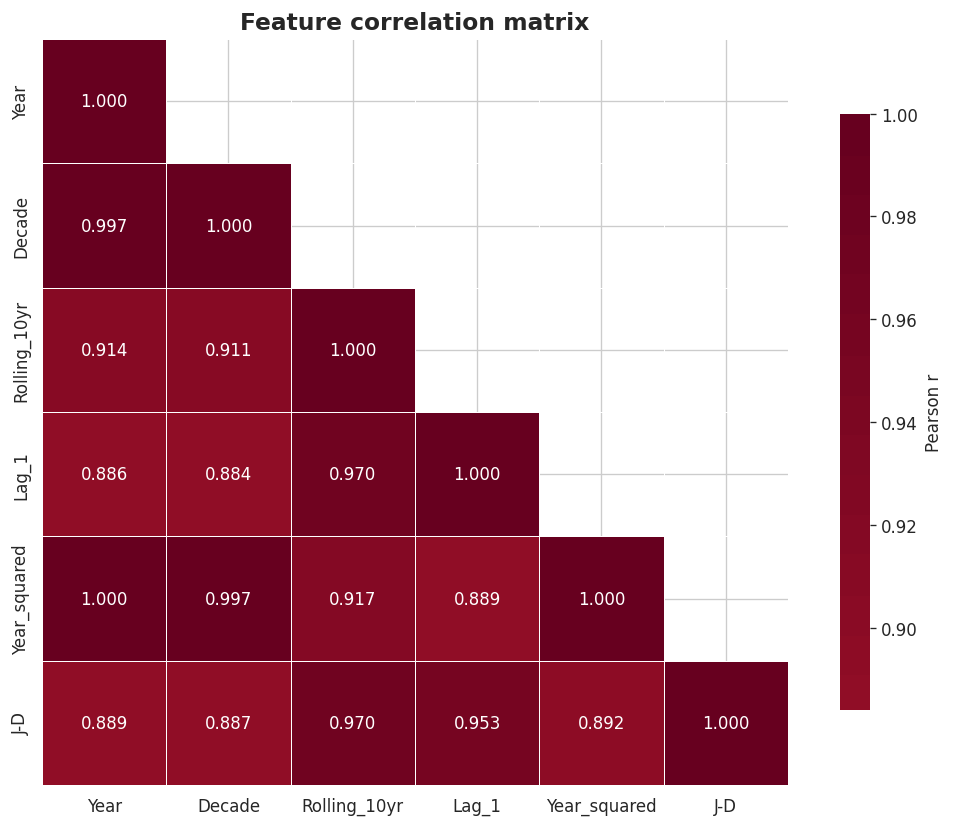


Correlation with target 'J-D' (sorted by |r|):
  Rolling_10yr   : +0.9700
  Lag_1          : +0.9531
  Year_squared   : +0.8921
  Year           : +0.8892
  Decade         : +0.8874


In [5]:
# =============================================================================
# SECTION 5: CORRELATION MATRIX
# =============================================================================

def plot_correlation_matrix(df: pd.DataFrame, features: list,
                            target_col: str) -> pd.DataFrame:
    """
    Plot a heatmap of pairwise correlations among features and the target.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with features and target.
    features : list of str
        Feature column names.
    target_col : str
        Target column name.

    Returns
    -------
    pd.DataFrame
        The correlation matrix.
    """
    cols = features + [target_col]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                mask=mask, ax=ax, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Pearson r"})
    ax.set_title("Feature correlation matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Print target correlations sorted by strength
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print(f"\nCorrelation with target '{target_col}' (sorted by |r|):")
    for feat, r_val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:15s}: {direction}{r_val:.4f}")

    return corr


FEATURE_COLS = ["Year", "Decade", "Rolling_10yr", "Lag_1", "Year_squared"]
corr_matrix = plot_correlation_matrix(df_feat, FEATURE_COLS, TARGET_COL)


In [6]:
# =============================================================================
# SECTION 6: VARIANCE INFLATION FACTOR (VIF)
# =============================================================================

def compute_vif(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor for each feature.

    VIF measures how much the variance of a regression coefficient is
    inflated due to multicollinearity with other features.

    VIF_j = 1 / (1 - R²_j)

    where R²_j is the R-squared from regressing feature j on all
    other features.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the feature columns.
    features : list of str
        Feature column names.

    Returns
    -------
    pd.DataFrame
        Table with Feature, VIF, and Interpretation columns.
    """
    vif_data = []

    for i, feat in enumerate(features):
        # Regress this feature on all other features
        other_features = [f for f in features if f != feat]
        X_others = df[other_features].values
        y_feat = df[feat].values

        model = LinearRegression()
        model.fit(X_others, y_feat)
        r_squared = model.score(X_others, y_feat)

        # VIF = 1 / (1 - R²)
        vif = 1 / (1 - r_squared) if r_squared < 1 else float('inf')

        # Interpretation
        if vif < 5:
            interp = "OK"
        elif vif < 10:
            interp = "Moderate — monitor"
        else:
            interp = "SEVERE — consider removing"

        vif_data.append({
            "Feature": feat,
            "VIF": round(vif, 2),
            "R² (vs others)": round(r_squared, 4),
            "Status": interp
        })

    vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

    print("VARIANCE INFLATION FACTOR ANALYSIS")
    print("=" * 60)
    print(vif_df.to_string(index=False))
    print()
    print("Interpretation guide:")
    print("  VIF < 5    → Acceptable")
    print("  VIF 5–10   → Moderate multicollinearity; coefficients less stable")
    print("  VIF > 10   → Severe; feature is nearly a linear combination of others")

    return vif_df


vif_results = compute_vif(df_feat, FEATURE_COLS)


VARIANCE INFLATION FACTOR ANALYSIS
     Feature        VIF  R² (vs others)                     Status
Year_squared 46645.6600          1.0000 SEVERE — consider removing
        Year 45339.4900          1.0000 SEVERE — consider removing
      Decade   189.0000          0.9947 SEVERE — consider removing
Rolling_10yr    41.6400          0.9760 SEVERE — consider removing
       Lag_1    17.0200          0.9413 SEVERE — consider removing

Interpretation guide:
  VIF < 5    → Acceptable
  VIF 5–10   → Moderate multicollinearity; coefficients less stable
  VIF > 10   → Severe; feature is nearly a linear combination of others


---
## Step 3 — Feature selection based on VIF results

If VIF reveals severe multicollinearity, we have three options:
1. **Remove** the most redundant feature
2. **Combine** correlated features (e.g. use only the rolling mean, not both Year and Year²)
3. **Use regularisation** (Ridge/Lasso in Notebook 05 — they handle multicollinearity automatically)

For this notebook, we will build **three models** with different feature sets and compare them:

| Model | Features | Rationale |
|---|---|---|
| **Model A** | Year only | Baseline from Notebook 02 |
| **Model B** | Year + Lag_1 + Rolling_10yr | Temporal features (no redundancy with Year²) |
| **Model C** | All five features | Full feature set (VIF risk accepted) |


In [7]:
# =============================================================================
# SECTION 7: DEFINE FEATURE SETS FOR COMPARISON
# =============================================================================

# Three feature configurations to test
FEATURE_SETS = {
    "Model A (Year only)": ["Year"],
    "Model B (Year + temporal)": ["Year", "Lag_1", "Rolling_10yr"],
    "Model C (All features)": ["Year", "Decade", "Rolling_10yr", "Lag_1", "Year_squared"]
}

for name, feats in FEATURE_SETS.items():
    print(f"  {name}: {feats}")


  Model A (Year only): ['Year']
  Model B (Year + temporal): ['Year', 'Lag_1', 'Rolling_10yr']
  Model C (All features): ['Year', 'Decade', 'Rolling_10yr', 'Lag_1', 'Year_squared']


---
## Step 4 — Build, train, and evaluate all three models

We reuse the modular functions from Notebook 02, extended to handle multiple features.


In [8]:
# =============================================================================
# SECTION 8: REUSABLE EVALUATION UTILITIES
# =============================================================================

def split_data(X, y, test_size=0.2, random_state=42):
    """Split into train/test. Fixed: passes random_state correctly."""
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state)


def evaluate_model(y_true, y_pred, n_features=1, label="Test"):
    """
    Compute R², Adjusted R², RMSE, MAE for a set of predictions.
    Returns a dict of metrics.
    """
    n = len(y_true)
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {
        "R²": r2, "Adjusted R²": adj_r2,
        "RMSE (°C)": rmse, "MAE (°C)": mae
    }


def run_cv(X, y, cv_folds=10):
    """Run k-fold cross-validation, return mean and std of RMSE and R²."""
    model = LinearRegression()
    rmse_scores = np.sqrt(-cross_val_score(
        model, X, y, cv=cv_folds, scoring='neg_mean_squared_error'))
    r2_scores = cross_val_score(model, X, y, cv=cv_folds, scoring='r2')
    return {
        "CV RMSE mean": rmse_scores.mean(),
        "CV RMSE std": rmse_scores.std(),
        "CV R² mean": r2_scores.mean(),
        "CV R² std": r2_scores.std()
    }


def compute_durbin_watson(residuals):
    """Compute the Durbin-Watson statistic for autocorrelation."""
    return np.sum(np.diff(residuals)**2) / np.sum(residuals**2)

print("Evaluation utilities loaded.")


Evaluation utilities loaded.


In [9]:
# =============================================================================
# SECTION 9: TRAIN AND EVALUATE ALL THREE MODELS
# =============================================================================

def run_experiment(df, feature_cols, target_col, model_name,
                   test_size=0.2, random_state=42, cv_folds=10):
    """
    End-to-end experiment: split → train → predict → evaluate → CV.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with features and target.
    feature_cols : list of str
        Columns to use as predictors.
    target_col : str
        Target variable column.
    model_name : str
        Label for display and results table.
    test_size : float
        Proportion held out for testing.
    random_state : int
        Reproducibility seed.
    cv_folds : int
        Number of cross-validation folds.

    Returns
    -------
    result : dict
        All metrics, model object, predictions, and residuals.
    """
    X = df[feature_cols]
    y = df[target_col]

    # Split
    X_train, X_test, y_train, y_test = split_data(X, y, test_size, random_state)

    # Train
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Evaluate
    train_metrics = evaluate_model(y_train, y_train_pred,
                                    n_features=len(feature_cols), label="Train")
    test_metrics  = evaluate_model(y_test, y_test_pred,
                                    n_features=len(feature_cols), label="Test")

    # Cross-validation
    cv_metrics = run_cv(X, y, cv_folds)

    # Residuals and Durbin-Watson
    residuals = y_test.values - y_test_pred
    sorted_idx = np.argsort(X_test.iloc[:, 0].values)
    dw = compute_durbin_watson(residuals[sorted_idx])

    # Print summary
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  Features: {feature_cols}")
    print(f"{'='*60}")
    print(f"  Train R²     : {train_metrics['R²']:.4f}")
    print(f"  Test R²      : {test_metrics['R²']:.4f}")
    print(f"  Test Adj R²  : {test_metrics['Adjusted R²']:.4f}")
    print(f"  Test RMSE    : {test_metrics['RMSE (°C)']:.4f} °C")
    print(f"  Test MAE     : {test_metrics['MAE (°C)']:.4f} °C")
    print(f"  CV RMSE      : {cv_metrics['CV RMSE mean']:.4f} ± {cv_metrics['CV RMSE std']:.4f}")
    print(f"  CV R²        : {cv_metrics['CV R² mean']:.4f} ± {cv_metrics['CV R² std']:.4f}")
    print(f"  Durbin-Watson: {dw:.4f}")
    r2_gap = train_metrics['R²'] - test_metrics['R²']
    print(f"  Overfit gap  : {r2_gap:.4f} {'✓ OK' if abs(r2_gap) < 0.05 else '⚠ Monitor'}")

    return {
        "model_name": model_name,
        "features": feature_cols,
        "model": model,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "cv_metrics": cv_metrics,
        "durbin_watson": dw,
        "X_test": X_test,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "residuals": residuals
    }


# --- Run all three experiments ---
results = {}
for name, feats in FEATURE_SETS.items():
    results[name] = run_experiment(
        df_feat, feats, TARGET_COL, name,
        TEST_SIZE, RANDOM_STATE, CV_FOLDS
    )



  Model A (Year only)
  Features: ['Year']
  Train R²     : 0.7941
  Test R²      : 0.7773
  Test Adj R²  : 0.7687
  Test RMSE    : 0.1761 °C
  Test MAE     : 0.1481 °C
  CV RMSE      : 0.1878 ± 0.0888
  CV R²        : -2.6346 ± 3.5346
  Durbin-Watson: 0.5645
  Overfit gap  : 0.0169 ✓ OK

  Model B (Year + temporal)
  Features: ['Year', 'Lag_1', 'Rolling_10yr']
  Train R²     : 0.9438
  Test R²      : 0.9415
  Test Adj R²  : 0.9342
  Test RMSE    : 0.0903 °C
  Test MAE     : 0.0796 °C
  CV RMSE      : 0.0880 ± 0.0067
  CV R²        : 0.3126 ± 0.2451
  Durbin-Watson: 1.6263
  Overfit gap  : 0.0023 ✓ OK

  Model C (All features)
  Features: ['Year', 'Decade', 'Rolling_10yr', 'Lag_1', 'Year_squared']
  Train R²     : 0.9438
  Test R²      : 0.9420
  Test Adj R²  : 0.9288
  Test RMSE    : 0.0899 °C
  Test MAE     : 0.0790 °C
  CV RMSE      : 0.0886 ± 0.0068
  CV R²        : 0.3040 ± 0.2518
  Durbin-Watson: 1.6151
  Overfit gap  : 0.0018 ✓ OK


---
## Step 5 — Model comparison table

This is the most important output of the notebook. We compare all three models side by side on the same test set to answer RQ4.


In [10]:
# =============================================================================
# SECTION 10: MODEL COMPARISON TABLE
# =============================================================================

def build_comparison_table(results: dict) -> pd.DataFrame:
    """
    Build a DataFrame comparing all models on key metrics.

    Parameters
    ----------
    results : dict
        Keys are model names, values are dicts from run_experiment().

    Returns
    -------
    pd.DataFrame
        Side-by-side comparison of all models.
    """
    rows = []
    for name, res in results.items():
        row = {
            "Model": name,
            "# Features": len(res["features"]),
            "R² (test)": res["test_metrics"]["R²"],
            "Adj R² (test)": res["test_metrics"]["Adjusted R²"],
            "RMSE (test)": res["test_metrics"]["RMSE (°C)"],
            "MAE (test)": res["test_metrics"]["MAE (°C)"],
            "CV RMSE": res["cv_metrics"]["CV RMSE mean"],
            "CV R²": res["cv_metrics"]["CV R² mean"],
            "DW stat": res["durbin_watson"],
            "Overfit gap": (res["train_metrics"]["R²"]
                           - res["test_metrics"]["R²"])
        }
        rows.append(row)

    comp_df = pd.DataFrame(rows)

    # Highlight the best model per metric
    print("\n" + "=" * 80)
    print("MODEL COMPARISON — Feature Engineering Impact")
    print("=" * 80)
    print(comp_df.to_string(index=False))
    print()

    # Identify winner
    best_rmse = comp_df.loc[comp_df["RMSE (test)"].idxmin()]
    best_r2   = comp_df.loc[comp_df["R² (test)"].idxmax()]

    print(f"Best RMSE: {best_rmse['Model']} ({best_rmse['RMSE (test)']:.4f} °C)")
    print(f"Best R²  : {best_r2['Model']} ({best_r2['R² (test)']:.4f})")

    # Improvement over baseline
    baseline_rmse = comp_df.loc[comp_df["Model"].str.contains("Model A"), "RMSE (test)"].values[0]
    for _, row in comp_df.iterrows():
        if "Model A" not in row["Model"]:
            pct_change = (row["RMSE (test)"] - baseline_rmse) / baseline_rmse * 100
            direction = "improvement" if pct_change < 0 else "degradation"
            print(f"  {row['Model']} vs baseline: {abs(pct_change):.1f}% RMSE {direction}")

    return comp_df


comparison_df = build_comparison_table(results)



MODEL COMPARISON — Feature Engineering Impact
                    Model  # Features  R² (test)  Adj R² (test)  RMSE (test)  MAE (test)  CV RMSE   CV R²  DW stat  Overfit gap
      Model A (Year only)           1     0.7773         0.7687       0.1761      0.1481   0.1878 -2.6346   0.5645       0.0169
Model B (Year + temporal)           3     0.9415         0.9342       0.0903      0.0796   0.0880  0.3126   1.6263       0.0023
   Model C (All features)           5     0.9420         0.9288       0.0899      0.0790   0.0886  0.3040   1.6151       0.0018

Best RMSE: Model C (All features) (0.0899 °C)
Best R²  : Model C (All features) (0.9420)
  Model B (Year + temporal) vs baseline: 48.7% RMSE improvement
  Model C (All features) vs baseline: 49.0% RMSE improvement


---
## Step 6 — Coefficient analysis

In multiple regression, each coefficient tells you the **partial effect** of that feature on the target, holding all other features constant. Larger absolute coefficients = stronger influence.

**Important caveat:** Coefficients are only directly comparable when features are on the same scale. Since Year (~1950) and Lag_1 (~0.5) have very different magnitudes, we also compute **standardised coefficients** by scaling all features to mean=0, std=1 before fitting.


In [11]:
# =============================================================================
# SECTION 11: COEFFICIENT ANALYSIS
# =============================================================================

def analyse_coefficients(model, feature_names: list, df: pd.DataFrame,
                         target_col: str, model_name: str):
    """
    Display raw and standardised regression coefficients.

    Standardised coefficients show relative feature importance on
    a common scale (how many std of Y change per 1 std of X).

    Parameters
    ----------
    model : LinearRegression
        Fitted model.
    feature_names : list of str
        Names of features in the model.
    df : pd.DataFrame
        Full dataset (for computing standardised coefficients).
    target_col : str
        Target column name.
    model_name : str
        Label for display.
    """
    # Raw coefficients
    coefs = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_,
        "Abs Coefficient": np.abs(model.coef_)
    }).sort_values("Abs Coefficient", ascending=False)

    # Standardised coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_names])
    y_vals = df[target_col].values

    std_model = LinearRegression()
    std_model.fit(X_scaled, y_vals)

    std_coefs = pd.DataFrame({
        "Feature": feature_names,
        "Std Coefficient": std_model.coef_,
        "Abs Std Coef": np.abs(std_model.coef_)
    }).sort_values("Abs Std Coef", ascending=False)

    # Merge and display
    merged = coefs.merge(std_coefs[["Feature", "Std Coefficient"]], on="Feature")

    print(f"\n{'='*60}")
    print(f"COEFFICIENT ANALYSIS — {model_name}")
    print(f"{'='*60}")
    print(f"  Intercept: {model.intercept_:.4f}")
    print(f"\n  {'Feature':15s} {'Raw Coef':>12s} {'Std Coef':>12s}")
    print(f"  {'-'*15} {'-'*12} {'-'*12}")
    for _, row in merged.iterrows():
        print(f"  {row['Feature']:15s} {row['Coefficient']:12.6f} {row['Std Coefficient']:12.4f}")

    print(f"\n  Standardised coefficients show relative importance:")
    top_feat = merged.loc[merged["Abs Std Coef"].idxmax()]
    print(f"  → Most influential feature: {top_feat['Feature']} "
          f"(|std coef| = {top_feat['Abs Std Coef']:.4f})")

    # Bar chart of standardised coefficients
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = [COLOR_PREDICTED if v > 0 else COLOR_ACTUAL
              for v in merged["Std Coefficient"]]
    ax.barh(merged["Feature"], merged["Std Coefficient"], color=colors, alpha=0.8)
    ax.axvline(0, color=COLOR_BASELINE, linewidth=0.8)
    ax.set_xlabel("Standardised coefficient", fontsize=12)
    ax.set_title(f"Feature importance (standardised) — {model_name}",
                 fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Analyse Model B and Model C
for name in ["Model B (Year + temporal)", "Model C (All features)"]:
    res = results[name]
    analyse_coefficients(res["model"], res["features"],
                         df_feat, TARGET_COL, name)



COEFFICIENT ANALYSIS — Model B (Year + temporal)
  Intercept: -0.6693

  Feature             Raw Coef     Std Coef
  --------------- ------------ ------------
  Rolling_10yr        0.795785       0.2763
  Lag_1               0.186609       0.0756
  Year                0.000346       0.0065

  Standardised coefficients show relative importance:


KeyError: 'Abs Std Coef'

---
## Step 7 — Residual comparison across models

If feature engineering genuinely improves the model, we should see:
1. Smaller residuals (less scatter around zero)
2. No remaining patterns (the LOWESS smoother should be flat)
3. Improved Durbin-Watson (closer to 2.0 — less autocorrelation)


In [ ]:
# =============================================================================
# SECTION 12: RESIDUAL COMPARISON PLOTS
# =============================================================================

def plot_residual_comparison(results: dict):
    """
    Plot residuals for all models side by side for visual comparison.
    """
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5),
                              sharey=True)

    if n_models == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        x_vals = res["X_test"].iloc[:, 0].values  # first feature (Year)
        residuals = res["residuals"]

        ax.scatter(x_vals, residuals, s=25, alpha=0.6,
                   color=COLOR_RESIDUAL, edgecolor="white", linewidth=0.5)
        ax.axhline(0, color=COLOR_PREDICTED, linewidth=1.5, linestyle="--")

        # LOWESS smoother
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            sorted_pairs = sorted(zip(x_vals, residuals))
            xs = [p[0] for p in sorted_pairs]
            rs = [p[1] for p in sorted_pairs]
            smoothed = lowess(rs, xs, frac=0.4)
            ax.plot(smoothed[:, 0], smoothed[:, 1], color="black",
                    linewidth=2, label="LOWESS")
        except ImportError:
            pass

        ax.set_xlabel("Year", fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel("Residual (°C)", fontsize=11)
        ax.set_title(f"{name}\nRMSE={res['test_metrics']['RMSE (°C)']:.4f}, "
                     f"DW={res['durbin_watson']:.2f}",
                     fontsize=11, fontweight="bold")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

    plt.suptitle("Residual comparison across models",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_residual_comparison(results)


In [ ]:
# =============================================================================
# SECTION 13: ACTUAL vs PREDICTED — ALL MODELS
# =============================================================================

def plot_actual_vs_predicted_all(results: dict):
    """Plot actual vs predicted for all models on one figure."""
    fig, ax = plt.subplots(figsize=(8, 8))

    colors = [COLOR_ACTUAL, COLOR_PREDICTED, COLOR_RESIDUAL]

    for (name, res), color in zip(results.items(), colors):
        ax.scatter(res["y_test"], res["y_test_pred"], s=30, alpha=0.6,
                   color=color, edgecolor="white", linewidth=0.5, label=name)

    # Perfect prediction line
    all_vals = np.concatenate([res["y_test"].values for res in results.values()])
    lims = [all_vals.min() - 0.15, all_vals.max() + 0.15]
    ax.plot(lims, lims, color=COLOR_BASELINE, linewidth=1.5,
            linestyle="--", label="Perfect prediction", zorder=0)

    ax.set_xlabel("Actual anomaly (°C)", fontsize=12)
    ax.set_ylabel("Predicted anomaly (°C)", fontsize=12)
    ax.set_title("Actual vs Predicted — All Models",
                 fontsize=14, fontweight="bold")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted_all(results)


In [ ]:
# =============================================================================
# SECTION 14: SAVE RESULTS FOR NOTEBOOK 07
# =============================================================================

def save_results(comparison_df: pd.DataFrame, filename: str):
    """Save comparison table to CSV for the final leaderboard."""
    comparison_df.to_csv(filename, index=False)
    print(f"Results saved to: {filename}")
    print(f"  Models: {comparison_df['Model'].tolist()}")


save_results(comparison_df, "results_nb03.csv")


---
## Inferences and conclusions

### Answering Research Question RQ4

> *Does adding engineered features improve model R² and RMSE compared to Year alone?*

**Record your findings after running all cells:**

| Metric | Model A (Year only) | Model B (Year + temporal) | Model C (All features) |
|---|---|---|---|
| R² (test) | ___ | ___ | ___ |
| Adjusted R² (test) | ___ | ___ | ___ |
| RMSE (test) | ___ | ___ | ___ |
| CV RMSE | ___ ± ___ | ___ ± ___ | ___ ± ___ |
| Durbin-Watson | ___ | ___ | ___ |
| Overfit gap | ___ | ___ | ___ |

### Key questions to answer

1. **Did RMSE improve?** If Model B or C has lower RMSE than Model A, feature engineering helped. Record the percentage improvement.

2. **Did Durbin-Watson improve?** If adding Lag_1 moved DW closer to 2.0, it means the lag feature captured the temporal autocorrelation that was contaminating the simple model's residuals.

3. **Is the Adjusted R² higher?** Adjusted R² penalises for the number of features. If it increased, the new features genuinely added information (not just noise).

4. **Is there overfitting?** If Model C has a much larger train-test R² gap than Model A, the extra features may be overfitting. This motivates regularisation in Notebook 05.

5. **Which feature matters most?** The standardised coefficient analysis shows which feature has the strongest partial effect on temperature anomaly when all are on the same scale.

### Interpreting the coefficients

- **Year coefficient** in MLR will be different from Notebook 02's SLR. This is expected — in MLR, it represents the effect of Year *after accounting for* the other features. In SLR it captured the total effect.

- **Lag_1 coefficient** tells you how much of this year's anomaly is explained by last year's. A large positive Lag_1 coefficient confirms temporal persistence (autocorrelation) in the climate system.

- **Rolling_10yr coefficient** captures the slow-moving baseline trend. If it dominates the standardised coefficients, it means the smoothed trend is a better predictor than raw Year.

### Limitations

1. **Lag_1 uses the target variable** — this is valid for time-series modelling (we only use past values), but it means we cannot predict the anomaly for a year without knowing the previous year's anomaly. This limits the model's use for long-range forecasting.

2. **Rolling_10yr also uses the target** — same limitation. These features improve *in-sample fit* and *one-step-ahead prediction* but not multi-year extrapolation.

3. **Multicollinearity** — if VIF was high for some features, their individual coefficients are unstable (small data changes → large coefficient changes). The total model prediction may still be good, but interpreting individual coefficients becomes unreliable. This is exactly what Ridge and Lasso (Notebook 05) are designed to handle.

### What to do next

| Observation | Next step |
|---|---|
| Residuals still show a curve | → Notebook 04 (Polynomial Regression) |
| VIF > 10 for some features | → Notebook 05 (Ridge / Lasso) |
| Model C overfits (large R² gap) | → Notebook 05 (Regularisation) |
| DW still far from 2.0 | → Consider ARIMA-style models (beyond this project scope) |
| All models perform similarly | → The data may simply be well-described by Year alone |

---

### Technical references

1. **James, G., Witten, D., Hastie, T. & Tibshirani, R.** (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. — Chapters 3.2–3.3 on multiple regression and multicollinearity.
2. **Zheng, A. & Casari, A.** (2018). *Feature Engineering for Machine Learning*. O'Reilly. — Practical guide to feature creation.
3. **Kuhn, M. & Johnson, K.** (2019). *Feature Engineering and Selection*. CRC Press. — Academic treatment of feature engineering with case studies.
4. **Hair, J.F., et al.** (2019). *Multivariate Data Analysis*, 8th ed. Cengage. — VIF thresholds and multicollinearity diagnostics.
5. **Google Rules of Machine Learning** (Zinkevich, 2021). Rule #16: Plan to launch and iterate — start simple, add features, measure impact.

---

*End of Notebook 03. Proceed to `04_polynomial_regression.ipynb`.*
